In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[2,1],[2,5],[3,8],[1,6],[2,9],[9,4]])

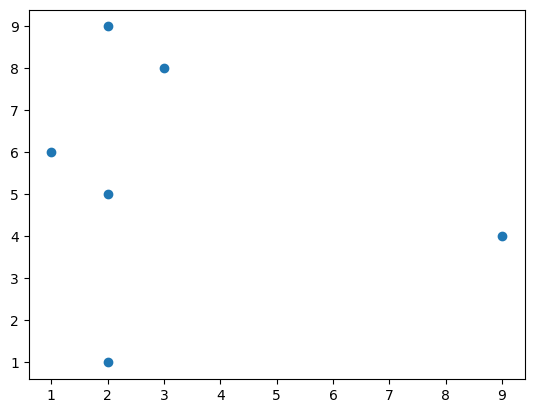

In [ ]:
plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [ ]:
db = DBSCAN(eps=3, min_samples=2).fit(X)

db.labels_

array([-1,  0,  0,  0,  0, -1])

In [ ]:
db = DBSCAN(eps=10, min_samples=2).fit(X)

db.labels_

array([0, 0, 0, 0, 0, 0])

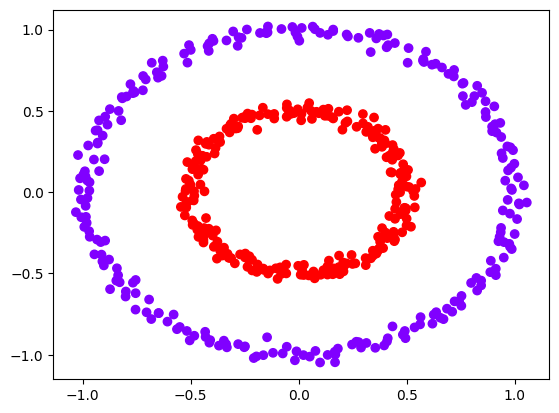

In [ ]:
from sklearn.datasets import make_circles

X, _ = make_circles(n_samples=500, factor=.5, noise=.03, random_state=4)

dbscan = DBSCAN(eps=0.1, min_samples=5)
clusters = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='rainbow', marker='o')
plt.show()

In [ ]:
from sklearn.datasets import make_blobs
from pandas import DataFrame

X, _ = make_blobs(n_samples=500, centers=4, n_features=2, random_state=20)

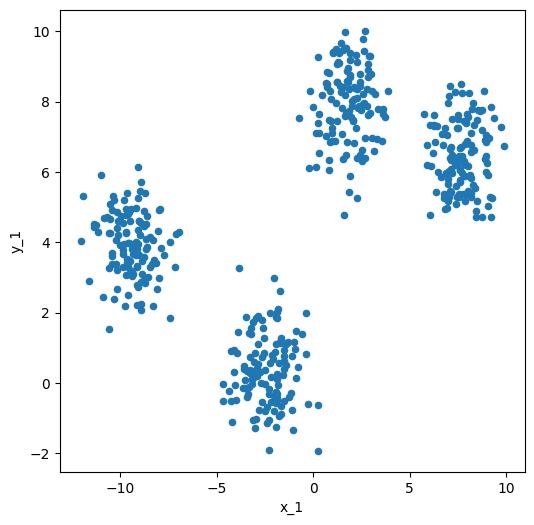

In [ ]:
df = DataFrame(dict(x=X[:, 0], y=X[:, 1]))
fig, ax = plt.subplots(figsize = (6,6))
df.plot(ax=ax, kind='scatter', x='x', y='y')
plt.xlabel('x_1')
plt.ylabel('y_1')
plt.show()

In [ ]:
clustering = DBSCAN(eps=1, min_samples=5).fit(X)
cluster = clustering.labels_
len(set(cluster))

5

In [ ]:
clustering.labels_

array([ 0,  0,  1,  0,  2,  0,  1,  1,  0,  2,  3,  1,  2,  1,  1,  2,  3,
        3,  2,  1,  3,  2,  2,  1,  0,  2,  0,  3,  0,  0,  0,  0,  2,  3,
        0,  1,  3,  3,  3,  0,  0,  2,  1,  0,  3,  1,  0,  2,  1,  0,  1,
        1,  1,  2,  1,  2,  1,  3,  1,  1,  0,  1,  1,  1,  2,  1,  3,  0,
        1,  3,  1,  2,  2,  1,  1,  2,  1,  3,  0,  1,  0,  2,  2, -1,  1,
        3,  1,  2,  1,  0,  0,  0,  3,  0,  3,  2,  1,  2,  1,  1,  1,  3,
        1,  2,  3,  3,  1,  1,  3,  0,  3,  0,  1,  1,  3,  1,  1,  1,  2,
        2,  0,  3,  1,  2,  3,  0,  3,  3,  3,  0,  1,  3,  3,  3,  0,  2,
        2,  1,  3,  0,  2,  2,  1,  3,  3,  2,  2,  0,  1,  0,  1,  2,  0,
        0,  0,  3,  3,  2,  0,  0,  2,  0,  0,  0,  3,  0,  1,  0,  3,  0,
        0,  1,  3,  3,  0,  2,  2,  1,  1,  0,  3,  0,  2,  2,  2,  2,  3,
        0,  0,  2,  1,  2,  3,  2,  3,  0,  2,  2,  3,  1,  0,  2,  2,  0,
        3,  3,  2,  0,  3,  0,  3,  2,  1,  3,  3,  1,  2,  2,  0,  1,  2,
        2,  1,  0,  0,  1

In [ ]:
np.sum(cluster == -1)

np.int64(2)

In [ ]:
def show_clusters(X, cluster):
  df = DataFrame(dict(x=X[:, 0], y=X[:, 1], label=cluster))
  colors = {-1:'red', 0:'blue', 1:'green', 2: 'yellow', 3: 'black'}
  fig, ax = plt.subplots(figsize = (8,8))
  grouped = df.groupby('label')
  for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
  plt.xlabel('x_1')
  plt.ylabel('y_1')
  plt.show()

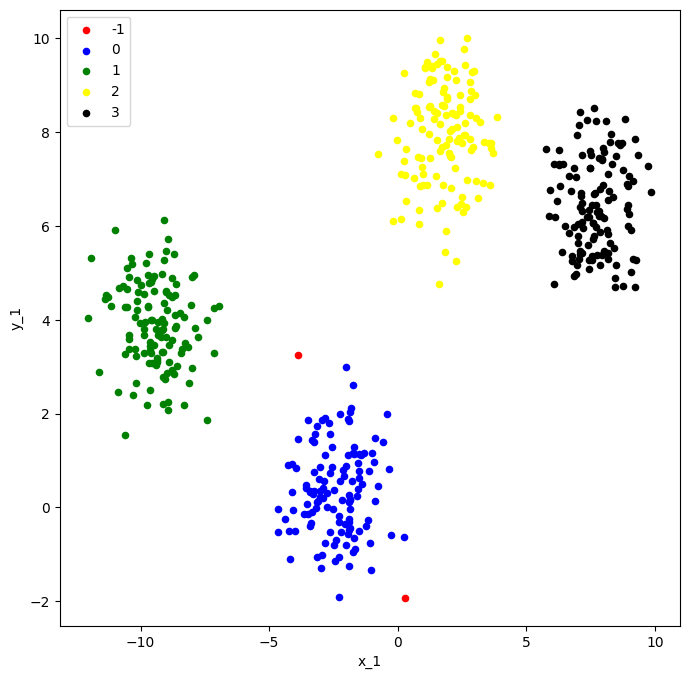

In [ ]:
show_clusters(X, cluster)

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv('Mall_Customers_sample.csv')

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db1  = DBSCAN(eps=1.2, min_samples=4)

clusters_before = db1.fit_predict(X_scaled)

In [ ]:
np.sum(clusters_before == -1)

np.int64(0)

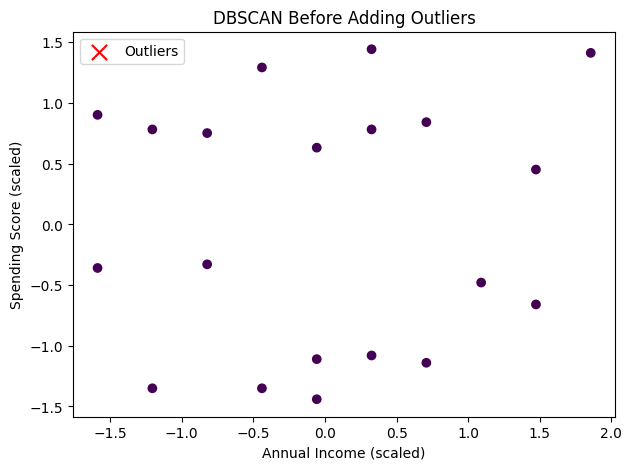

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=clusters_before,
            cmap='viridis')

plt.scatter(X_scaled[clusters_before==-1,0],
            X_scaled[clusters_before==-1,1],
            color='red',
            marker='x',
            s=120,
            label='Outliers')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("DBSCAN Before Adding Outliers")
plt.legend()
plt.show()


In [ ]:
new_points = np.array([[200,3], [5,95], [210,2]])

X_new = np.vstack([X.values, new_points])

In [ ]:
X_new_scaled = scaler.fit_transform(X_new)

db2  = DBSCAN(eps=1.2, min_samples=4)

clusters_after = db2.fit_predict(X_new_scaled)

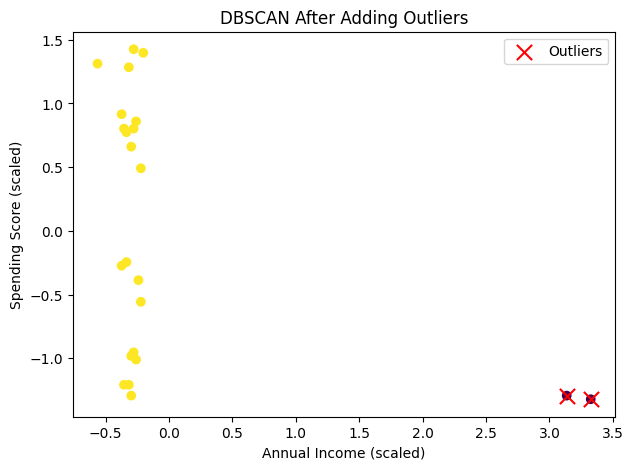

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(X_new_scaled[:,0], X_new_scaled[:,1],
            c=clusters_after,
            cmap='viridis')

plt.scatter(X_new_scaled[clusters_after==-1,0],
            X_new_scaled[clusters_after==-1,1],
            color='red',
            marker='x',
            s=120,
            label='Outliers')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("DBSCAN After Adding Outliers")
plt.legend()
plt.show()

In [ ]:
np.sum(clusters_after == -1)

np.int64(2)

In [ ]:
np.sum(clusters_after != -1)

np.int64(21)

##Conclusion:
The DBSCAN algorithm successfully identified new data points as outliers, demonstrating its robustness to noise. Additionally, it integrated relevant new points into existing clusters, showcasing its ability to adapt to changes in data distribution.